Importações de Bibliotecas

In [412]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import io

In [413]:
dados = pd.read_csv('../Prata.csv', sep=';', encoding='utf-8', decimal=',')
dados.tail(20)

,data_Lançamento,1. Pessoal Ativo,2. Pessoal Inativo e Pensionistas,4. Indenizações por Demissão e Incentivo à Demissão,5. Decorrentes de Decisão Judicial,6. Despesas de Exercicios Anteriores,7. Inativos e Pensionistas com Recursos Vinculados,9. Receita Corrente,10. Deduções
127,08-2024,9.159031e+08,6.669900e+08,997281.2,0.0,800581.2,1.918020e+08,4.753895e+09,1.239725e+09
128,09-2024,9.654408e+08,6.675743e+08,1184812.0,0.0,1038322.4,2.182234e+08,4.603217e+09,1.194247e+09
129,10-2024,1.148392e+09,6.815468e+08,1746846.7,63971.1,2178769.0,2.227669e+08,4.623710e+09,1.437768e+09
130,11-2024,9.434185e+08,5.868478e+08,819858.6,0.0,2992505.0,2.232093e+08,4.957853e+09,1.280028e+09
131,12-2024,2.294684e+09,1.315921e+09,1166479.6,407623572.8,1215519.6,3.934379e+08,5.373587e+09,1.888398e+09
132,01-2025,1.007702e+09,6.708176e+08,NaN,NaN,NaN,2.204016e+08,5.652536e+09,1.155264e+09
133,02-2025,9.816163e+08,6.751124e+08,NaN,NaN,NaN,2.054635e+08,5.687448e+09,1.634755e+09
134,03-2025,9.609695e+08,6.769911e+08,NaN,NaN,NaN,1.961541e+08,4.727752e+09,1.293003e+09
135,04-2025,9.602988e+08,6.766460e+08,NaN,NaN,NaN,2.038257e+08,4.871807e+09,1.375843e+09
136,05-2025,9.645936e+08,6.758968e+08,NaN,NaN,NaN,2.370245e+08,5.013924e+09,1.361954e+09


In [414]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 9 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   data_Lançamento                                      147 non-null    object 
 1   1. Pessoal Ativo                                     146 non-null    float64
 2   2. Pessoal Inativo e Pensionistas                    146 non-null    float64
 3   4. Indenizações por Demissão e Incentivo à Demissão  132 non-null    float64
 4   5. Decorrentes de Decisão Judicial                   132 non-null    float64
 5   6. Despesas de Exercicios Anteriores                 132 non-null    float64
 6   7. Inativos e Pensionistas com Recursos Vinculados   146 non-null    float64
 7   9. Receita Corrente                                  135 non-null    float64
 8   10. Deduções                                         135 non-null    fl

In [415]:
dados['Data'] = pd.to_datetime(dados['data_Lançamento'], format='%m-%Y')

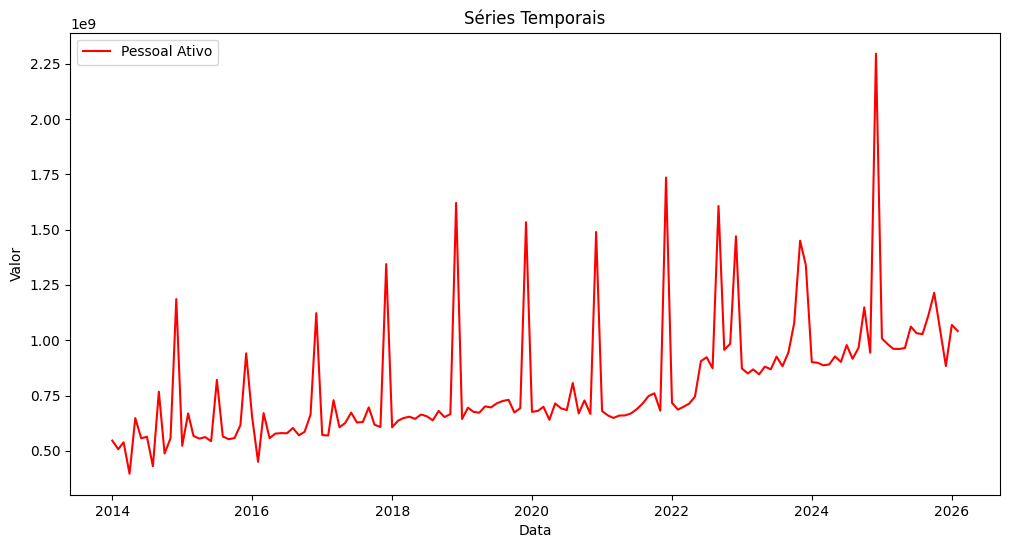

In [416]:
plt.figure(figsize=(12, 6))

plt.plot('Data', '1. Pessoal Ativo', data=dados, label='Pessoal Ativo',  linestyle='-', color='red')
plt.title('Séries Temporais')
plt.legend() 
plt.xlabel('Data')
plt.ylabel('Valor')
plt.show()

In [417]:
PA = pd.DataFrame(dados[['Data','1. Pessoal Ativo']])
PA = PA.dropna()

Gráficos ACF e PACF: Pessoal Ativo

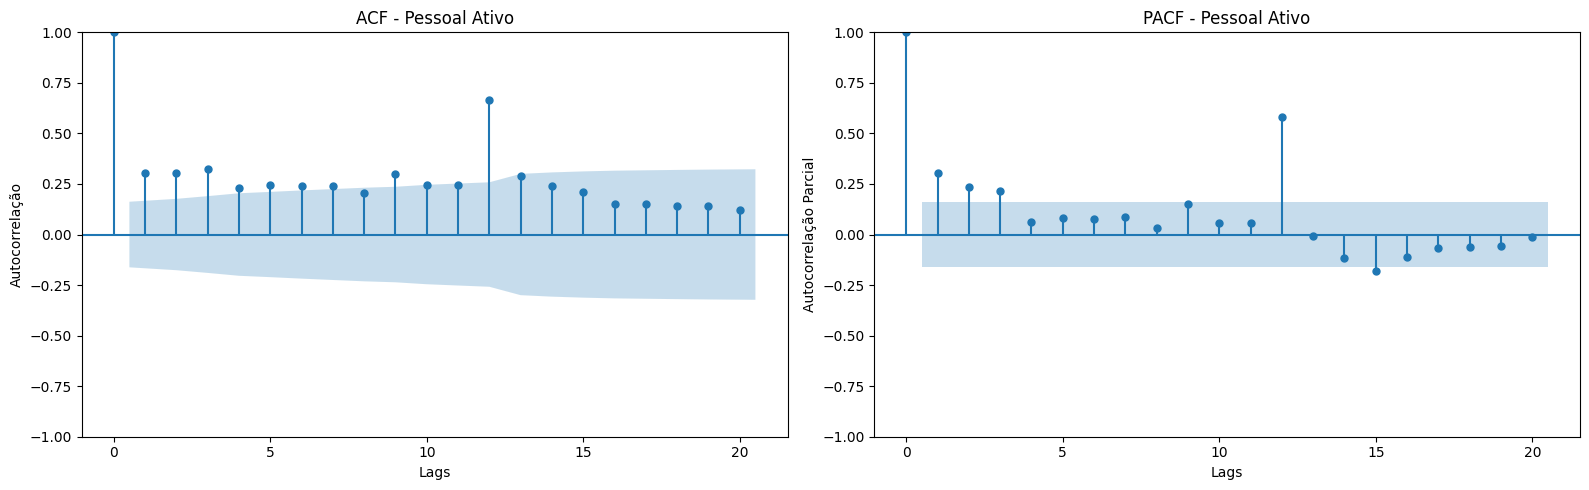

In [418]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(PA['1. Pessoal Ativo'], ax=axes[0], lags=20)
axes[0].set_title('ACF - Pessoal Ativo')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelação')  
plot_pacf(PA['1. Pessoal Ativo'], ax=axes[1], lags=20)
axes[1].set_title('PACF - Pessoal Ativo')   
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Autocorrelação Parcial')
plt.tight_layout()
plt.show()    


Crianção de Lags

In [419]:
PA.set_index('Data', inplace=True)
for i in range(1, 4):
    PA[f'Lag {i}'] = PA['1. Pessoal Ativo'].shift(i)
PA.dropna(inplace=True)

In [420]:
#PA.reset_index(drop=True, inplace=True)
PA.head()

,1. Pessoal Ativo,Lag 1,Lag 2,Lag 3
Data,,,,
2014-04-01,396504353.4,538507826.7,507208402.1,546275104.8
2014-05-01,647862745.1,396504353.4,538507826.7,507208402.1
2014-06-01,556555798.3,647862745.1,396504353.4,538507826.7
2014-07-01,563626632.7,556555798.3,647862745.1,396504353.4
2014-08-01,430233726.7,563626632.7,556555798.3,647862745.1


In [421]:
PA.tail(10)

,1. Pessoal Ativo,Lag 1,Lag 2,Lag 3
Data,,,,
2025-05-01,9.645936e+08,9.602988e+08,9.609695e+08,9.816163e+08
2025-06-01,1.061595e+09,9.645936e+08,9.602988e+08,9.609695e+08
2025-07-01,1.031537e+09,1.061595e+09,9.645936e+08,9.602988e+08
2025-08-01,1.027499e+09,1.031537e+09,1.061595e+09,9.645936e+08
2025-09-01,1.112812e+09,1.027499e+09,1.031537e+09,1.061595e+09
2025-10-01,1.213996e+09,1.112812e+09,1.027499e+09,1.031537e+09
2025-11-01,1.046065e+09,1.213996e+09,1.112812e+09,1.027499e+09
2025-12-01,8.831733e+08,1.046065e+09,1.213996e+09,1.112812e+09
2026-01-01,1.068828e+09,8.831733e+08,1.046065e+09,1.213996e+09


Dividindo entre treino e teste

In [422]:
y = PA['1. Pessoal Ativo'].values.reshape(-1, 1).astype(float)
X = PA.drop(columns=['1. Pessoal Ativo']).values.astype(float)

In [423]:
X.shape, y.shape

((143, 3), (143, 1))

In [424]:
PA.index[128]

Timestamp('2024-12-01 00:00:00')

In [425]:
X_train = X[:128]
y_train = y[:128]
X_test  = X[128:]
y_test  = y[128:]

In [426]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((128, 3), (128, 1), (15, 3), (15, 1))

Normalizando os Dados

In [427]:
#Scaler para as Features X
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

#Scaler para o Alvo y
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [428]:
print(f"Máximo no X do treino: {X_train_scaled.max()}, Mínimo: {X_train_scaled.min()}")
print(f"Máximo no X do teste: {X_test_scaled.max()}, Mínimo: {X_test_scaled.min()}")
print(f"Máximo no y do treino: {y_train_scaled.max()}, Mínimo: {y_train_scaled.min()}")
print(f"Máximo no y do teste: {y_test_scaled.max()}, Mínimo: {y_test_scaled.min()}")

Máximo no X do treino: 1.0, Mínimo: 0.0
Máximo no X do teste: 1.41803087289407, Mínimo: 0.36356486147397876
Máximo no y do treino: 1.0, Mínimo: 0.0
Máximo no y do teste: 1.41803087289407, Mínimo: 0.36356486147397876


Definição de Hiperparâmetros

In [429]:
hiperparametros = {
    'TAXA_DE_APRENDIZADO': 0.001,
    'EPOCAS': 300,
    'TAMANHO_LOTE': 12,
    'ENTRADAS': 32,
    'UNIDADES_OCULTAS': 16,
    'ATIVACAO': 'linear',
    'RANDOM_STATE': 42
}

In [430]:
#Construção da arquitetura

#Camada de Entrada
model_mlp = Sequential([Dense(hiperparametros['ENTRADAS'], # 64 Neurônio nesta camada (Z = W*X + b)
                                  input_shape=(X_train_scaled.shape[1],), # Quantidade de variáveis que vão entrar ( Z = w1*x1 + w2*x2 + b)
                                  activation=hiperparametros['ATIVACAO']) ]) # Especificando qual vai ser o tipo de ativação. Ex: reLu, linear, tanh, sigmoid...


#Camada Oculta 1
model_mlp.add(Dense(hiperparametros['UNIDADES_OCULTAS'], activation=hiperparametros['ATIVACAO']))

#Camada de Saída
model_mlp.add(Dense(1, activation=hiperparametros['ATIVACAO'])) # 1 Neurônio nesta camada (Z = W*X + b) --- IGNORE ---, ativação linear para regressão


#Configuração
model_mlp.compile(
    optimizer=Adam(learning_rate=hiperparametros['TAXA_DE_APRENDIZADO']), #Aplicação do modelo de Gradiente descendente, usando o leanning rate proposto
    loss='mse', # Qual a função da loss. Nesse caso o mse é (Z - F(x1,x2))²
    metrics=['mae'] # Erro Médio Absoluto para termos uma métrica mais legível
)

#Treinamento
historico = model_mlp.fit(
    X_train_scaled, y_train_scaled, #Indica quais são as bases
    epochs=hiperparametros['EPOCAS'], batch_size=hiperparametros['TAMANHO_LOTE'], #O batch_size é a batelada de cada iteração (epoch) que será calculada
    shuffle=False, # Manter a ordem temporal dos dados
    verbose=1 # Mude para 1 se quiser ver o log de cada época
)

Epoch 1/300


c:\Projeto Series Temporais\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0547 - mae: 0.1681  
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0363 - mae: 0.1493 
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0348 - mae: 0.1333 
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0314 - mae: 0.1063 
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0300 - mae: 0.1122 
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0312 - mae: 0.1198 
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0310 - mae: 0.1147 
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0307 - mae: 0.1144 
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0309 - mae: 0.1162 
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0309 - mae: 0.1154 
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0308 - mae: 0.1152 
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0309 - mae: 0.1156 
Epoch 13/300
11/11 ━━━━━━━━━━━━━━━━━

In [431]:
model_mlp.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,021 (7.90 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,348 (5.27 KB)

In [432]:
# get_weights() retorna uma lista: o primeiro item é a matriz de pesos (W), o segundo é o viés (b)
pesos, vies = model_mlp.get_layer(index=0).get_weights()

print(f"pesos: {pesos.flatten()} e o viés: {vies[0]:.4f}")

pesos: [-0.09937025 -0.19273505  0.25535697  0.24769258 -0.25013962  0.21388967
 -0.22240941  0.03704831  0.20005131  0.1302267  -0.00465564 -0.20117338
 -0.07570095  0.12720388 -0.11360874 -0.22084457 -0.08160646  0.07001264
  0.09509113  0.38595414 -0.00702679 -0.03649562  0.05816295 -0.37005466
  0.00093088  0.04044348  0.29293266  0.06250928 -0.07993297 -0.25873938
  0.18525943 -0.23084164  0.02818483 -0.1296325   0.03985577  0.21687432
 -0.37063667 -0.31026596  0.24802205 -0.21895562  0.07585871 -0.11412759
 -0.2844661   0.23723538 -0.21683368  0.21359031  0.19053613 -0.18632294
  0.04325569  0.17051524  0.27460203 -0.2925216   0.2051645  -0.28974143
 -0.299459    0.35209408  0.32358304  0.10428074 -0.18856226 -0.16466479
  0.14661334 -0.08603493 -0.05879577  0.00622349 -0.05721438  0.15980959
 -0.06503051  0.10022622 -0.11991267  0.10862366 -0.19938356  0.09763412
 -0.13935743  0.07115458  0.20173976  0.29747003  0.2210633  -0.26481515
 -0.21760367  0.18545833 -0.22152613  0.2211

In [433]:
data_min = scaler.data_min_
scale = scaler.scale_

# w = pesos / scale (scale is the range: 1/(max - min))
w = pesos / scale[:, np.newaxis]
b_raw = vies - np.dot(data_min, w)

w_escalar = w[0][0]
b_raw_escalar = b_raw[0]

print(f"Pesos desnormalizados: {w.flatten()}")
print(f"Viés desnormalizado: {b_raw_escalar:.4f}")

Pesos desnormalizados: [-1.88622615e+08 -3.65845803e+08  4.84713480e+08  4.70165103e+08
 -4.74810023e+08  4.06001093e+08 -4.22173091e+08  7.03243528e+07
  3.79733384e+08  2.47193716e+08 -8.83723571e+06 -3.81863280e+08
 -1.43694019e+08  2.41455860e+08 -2.15649835e+08 -4.19202732e+08
 -1.54903738e+08  1.32896598e+08  1.80500086e+08  7.32610419e+08
 -1.33381106e+07 -6.92752590e+07  1.10403739e+08 -7.02430346e+08
  1.76698709e+06  7.67690035e+07  5.56038905e+08  1.18653855e+08
 -1.51727153e+08 -4.91133911e+08  3.51655742e+08 -4.38178970e+08
  5.34998854e+07 -2.46065820e+08  7.56534327e+07  4.11666482e+08
 -7.03535105e+08 -5.88940626e+08  4.70790486e+08 -4.15617174e+08
  1.43993488e+08 -2.16634707e+08 -5.39967829e+08  4.50315450e+08
 -4.11589349e+08  4.05432846e+08  3.61671858e+08 -3.53674476e+08
  8.21070851e+07  3.23668611e+08  5.21244064e+08 -5.55258633e+08
  3.89439157e+08 -5.49981372e+08 -5.68427094e+08  6.68337937e+08
  6.14218838e+08  1.97943612e+08 -3.57925103e+08 -3.12563406e+08
  

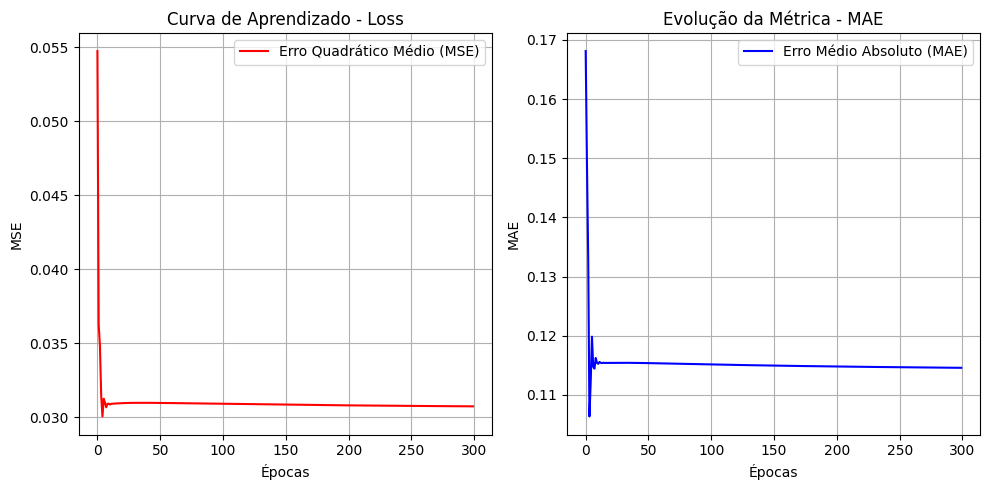

In [434]:
plt.figure(figsize=(10, 5))

# Plotando a Perda (MSE)
plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Erro Quadrático Médio (MSE)', color='red')
plt.title('Curva de Aprendizado - Loss')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# Plotando a Métrica (MAE)
plt.subplot(1, 2, 2)
plt.plot(historico.history['mae'], label='Erro Médio Absoluto (MAE)', color='blue')
plt.title('Evolução da Métrica - MAE')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [435]:
erro_simples = model_mlp.evaluate(X_test_scaled, y_test_scaled, verbose=0)[1]
print(f"Erro Médio Absoluto (Simples): {erro_simples:.2f}\n")

Erro Médio Absoluto (Simples): 0.16



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


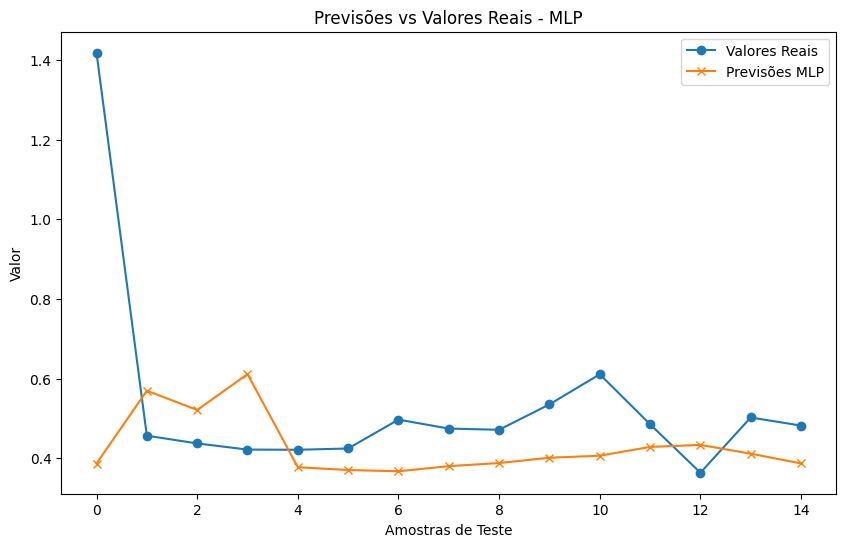

In [436]:
plt.figure(figsize=(10, 6))
y_pred = model_mlp.predict(X_test_scaled)   
plt.plot(y_test_scaled, label='Valores Reais', marker='o')
plt.plot(y_pred, label='Previsões MLP', marker='x')
plt.title('Previsões vs Valores Reais - MLP')
plt.xlabel('Amostras de Teste')
plt.ylabel('Valor')
plt.legend()